# Place-field pipeline: input-output correlation

The network is fed the animal's true grid/place-cell input (`obs[2]`) at each
timestep and trained to predict it (its own `obs_pred` for that channel). This
notebook computes **input** place fields (from `obs[2]`) and **output** place
fields (from the network's own prediction) for two demo networks, correlates
them cell-by-cell, and produces a figure.

Two demo networks are included in `nets/` (both with same seed to contrast):
- `base_no_reward_s1001_ep5` — no reward in the environment (baseline)
- `random_rew_mult5_s1001_ep5` — random behavior, reward present with multiplier 5

Canonical analysis functions live in `src/spatial_analysis.py`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from prnn.utils.predictiveNet import PredictiveNet
import spatial_analysis as sa

DATA_DIR = REPO_ROOT / "data" / "trajectory"

wandb not installed, will not log to wandb


## 1. Load the shared trajectory and the two demo networks

In [2]:
OBS = [torch.tensor(np.load(DATA_DIR / f"obs{i}.npy")) for i in range(4)]
ACT = torch.tensor(np.load(DATA_DIR / "act.npy"))
STATE = {
    "agent_pos": torch.tensor(np.load(DATA_DIR / "pos.npy")),
    "agent_dir": torch.tensor(np.load(DATA_DIR / "dir.npy")),
    "mean_vel": 0.2,
}

nets = {
    "base_no_reward": PredictiveNet.loadNet("base_no_reward_s1001_ep5", savefolder=str(REPO_ROOT) + "/", dil=False),
    "random_rew_mult5": PredictiveNet.loadNet("random_rew_mult5_s1001_ep5", savefolder=str(REPO_ROOT) + "/", dil=False),
}
for name, net in nets.items():
    print(name, "->", type(net.pRNN).__name__)

Net Loaded from pathname
Net Loaded from pathname
base_no_reward -> multRNN_5win_i2_o2
random_rew_mult5 -> multRNN_5win_i2_o23


## 2. Compute input and output place fields, and correlate them cell-by-cell

In [3]:
results = {}
for name, net in nets.items():
    env = net.EnvLibrary[0]
    pf_in, SI_in, _ = sa.calculateInputSpatialRepresentation(net, env, OBS, ACT, STATE, saveTrainingData=False)
    pf_out, SI_out, _ = sa.calculateOutputSpatialRepresentation(net, env, OBS, ACT, STATE, saveTrainingData=False)

    # Global (1D, whole-map) Pearson correlation per cell
    per_cell_corr = np.array([
        sa.take_correlation_2d(np.asarray(pf_in[c]).ravel(), np.asarray(pf_out[c]).ravel())
        for c in sorted(pf_in.keys())
    ])
    results[name] = dict(env=env, pf_in=pf_in, pf_out=pf_out, per_cell_corr=per_cell_corr)
    print(f"{name}: mean input-output correlation across {len(per_cell_corr)} cells = {np.nanmean(per_cell_corr):.3f}")

/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


base_no_reward: mean input-output correlation across 150 cells = 0.912


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


random_rew_mult5: mean input-output correlation across 150 cells = 0.945


## 3. Example cell: input vs. output place field, and their windowed 2D correlation map

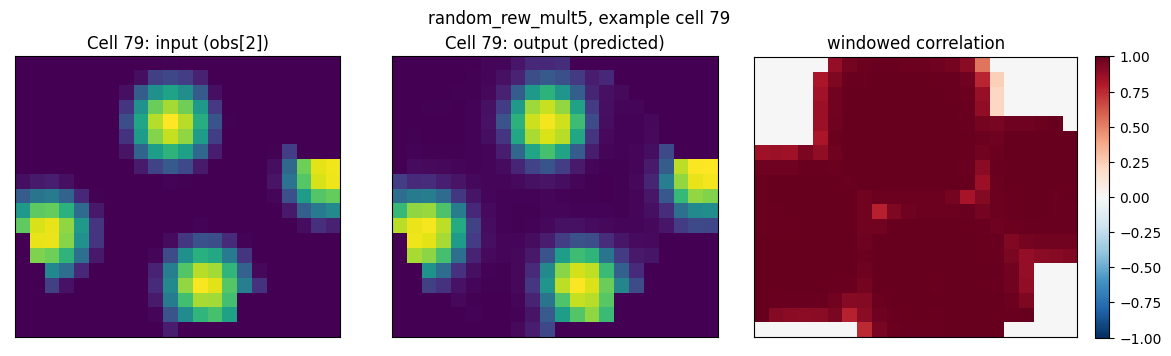

In [4]:
name = "random_rew_mult5"
pf_in, pf_out = results[name]["pf_in"], results[name]["pf_out"]
# pick a well-sampled example cell (highest input spatial extent)
example_cell = max(pf_in.keys(), key=lambda c: np.nanstd(pf_in[c]))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
im0 = axes[0].imshow(np.asarray(pf_in[example_cell]).T, origin="lower", cmap="viridis")
axes[0].set_title(f"Cell {example_cell}: input (obs[2])")
im1 = axes[1].imshow(np.asarray(pf_out[example_cell]).T, origin="lower", cmap="viridis")
axes[1].set_title(f"Cell {example_cell}: output (predicted)")
corr_map = sa.take_correlation_2d(np.asarray(pf_in[example_cell]), np.asarray(pf_out[example_cell]))
im2 = axes[2].imshow(corr_map.T, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title("windowed correlation")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046)
fig.suptitle(f"{name}, example cell {example_cell}")
fig.tight_layout()
plt.show()

An idea for using this method and data is take an average correlation across all seeds and conditions to then plot a summary figure.